In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('/content/Consumer_Complaints (1).csv')

In [5]:
import ipywidgets as widgets
from IPython.display import display

In [6]:
data.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer Complaint,Company Public Response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date Sent to Company,Company Response to Consumer,Timely response?,Consumer disputed?,Complaint ID
0,03-12-2014,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,M&T BANK CORPORATION,MI,48382,NaN,NaN,Referral,3/17/14,Closed with explanation,Yes,No,759217
1,10-01-2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,NaN,Consent provided,Web,10-05-2016,Closed with explanation,Yes,No,2141773
2,10/17/16,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,Older American,Consent provided,Web,10/20/16,Closed with explanation,Yes,No,2163100
3,06-08-2014,Credit card,NaN,Bankruptcy,NaN,NaN,NaN,AMERICAN EXPRESS COMPANY,ID,83854,Older American,NaN,Web,06-10-2014,Closed with explanation,Yes,Yes,885638
4,9/13/14,Debt collection,Credit card,Communication tactics,Frequent or repeated calls,NaN,NaN,"CITIBANK, N.A.",VA,23233,NaN,NaN,Web,9/13/14,Closed with explanation,Yes,Yes,1027760


### Step 1: Data Exploration and Preprocessing

To build a classification model, we first need to understand our target variable and the features that will help us predict it. We'll start by looking at the `Product` column, which we can use as our target to classify complaints to different departments. We'll also examine the text columns (`Consumer Complaint`, `Issue`, `Sub-issue`) for potential features.

In [7]:
# Check the distribution of the 'Product' column
print("Distribution of Products (potential departments):")
display(data['Product'].value_counts())

# Check for missing values in relevant columns
print("\nMissing values in key columns:")
relevant_columns = ['Product', 'Issue', 'Sub-issue', 'Consumer Complaint']
display(data[relevant_columns].isnull().sum().sort_values(ascending=False))

Distribution of Products (potential departments):


,count
Product,
Mortgage,2919
Debt collection,1904
Credit reporting,1821
Credit card,1162
Bank account or service,1090
Student loan,422
Consumer Loan,393
Money transfers,71
Payday loan,70



Missing values in key columns:


,0
Consumer Complaint,7885
Sub-issue,5847
Issue,0
Product,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Date received                 9999 non-null   object
 1   Product                       9999 non-null   object
 2   Sub-product                   6946 non-null   object
 3   Issue                         9999 non-null   object
 4   Sub-issue                     4152 non-null   object
 5   Consumer Complaint            2114 non-null   object
 6   Company Public Response       2694 non-null   object
 7   Company                       9999 non-null   object
 8   State                         9913 non-null   object
 9   ZIP code                      9913 non-null   object
 10  Tags                          1411 non-null   object
 11  Consumer consent provided?    4005 non-null   object
 12  Submitted via                 9999 non-null   object
 13  Date Sent to Compa

In [9]:
complaint_counts = data.groupby('Product').size()
display(complaint_counts)

,0
Product,
Bank account or service,1090
Checking or savings account,9
Consumer Loan,393
Credit card,1162
Credit card or prepaid card,12
Credit reporting,1821
"Credit reporting, credit repair services, or other personal consumer reports",59
Debt collection,1904
"Money transfer, virtual currency, or money service",7


/tmp/ipykernel_1330/4256988131.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


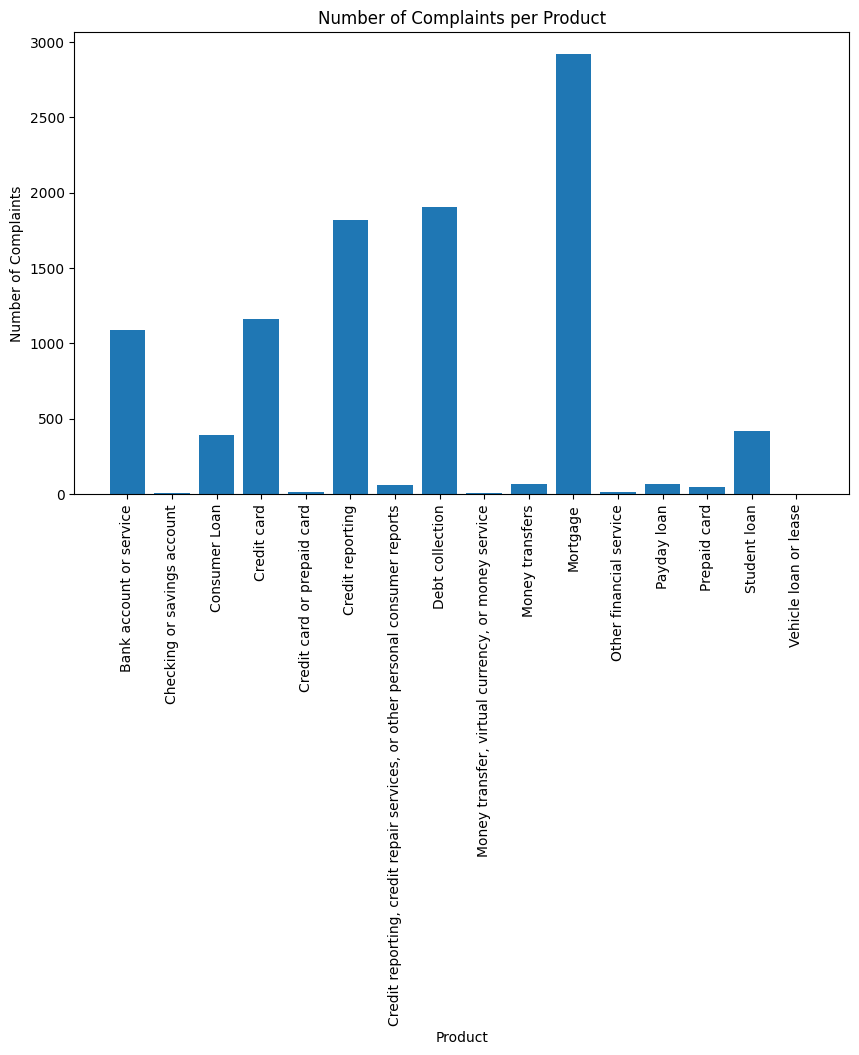

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(complaint_counts.index, complaint_counts.values)
plt.xticks(rotation=90)
plt.xlabel('Product')
plt.ylabel('Number of Complaints')
plt.title('Number of Complaints per Product')
plt.tight_layout()
plt.show()

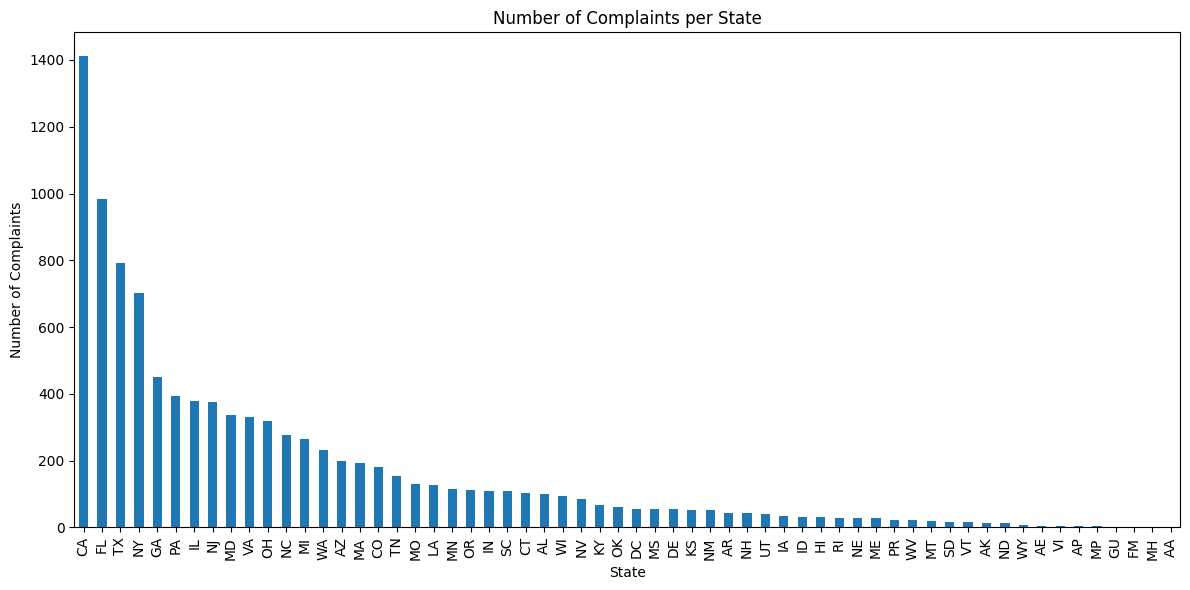

In [11]:
state_complaint_counts = data.groupby('State').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
state_complaint_counts.plot(kind='bar')
plt.xlabel('State')
plt.ylabel('Number of Complaints')
plt.title('Number of Complaints per State')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
top_states = state_complaint_counts.sort_values(ascending=False).head(15).index.tolist()
display(top_states)

['CA',
 'FL',
 'TX',
 'NY',
 'GA',
 'PA',
 'IL',
 'NJ',
 'MD',
 'VA',
 'OH',
 'NC',
 'MI',
 'WA',
 'AZ']

In [13]:
state_product_counts = data.groupby(['State', 'Product']).size()
state_product_counts_top_states = state_product_counts.loc[top_states]
pivot_table = state_product_counts_top_states.unstack()
display(pivot_table)

Product,Bank account or service,Checking or savings account,Consumer Loan,Credit card,Credit card or prepaid card,Credit reporting,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,"Money transfer, virtual currency, or money service",Money transfers,Mortgage,Other financial service,Payday loan,Prepaid card,Student loan,Vehicle loan or lease
State,,,,,,,,,,,,,,,,
CA,151.0,6.0,43.0,171.0,3.0,215.0,2.0,249.0,1.0,8.0,495.0,1.0,10.0,5.0,52.0,NaN
FL,103.0,NaN,33.0,94.0,2.0,207.0,8.0,165.0,NaN,5.0,341.0,NaN,2.0,3.0,22.0,NaN
TX,78.0,NaN,42.0,72.0,1.0,202.0,4.0,204.0,1.0,6.0,145.0,NaN,9.0,3.0,26.0,NaN
NY,104.0,1.0,19.0,100.0,2.0,126.0,6.0,110.0,1.0,5.0,190.0,1.0,NaN,4.0,32.0,NaN
GA,38.0,NaN,21.0,44.0,NaN,110.0,4.0,86.0,NaN,1.0,126.0,NaN,NaN,5.0,17.0,NaN
PA,45.0,NaN,15.0,44.0,NaN,77.0,2.0,76.0,1.0,4.0,100.0,1.0,5.0,1.0,23.0,NaN
IL,49.0,NaN,15.0,46.0,1.0,73.0,2.0,73.0,1.0,7.0,93.0,NaN,2.0,1.0,17.0,NaN
NJ,50.0,1.0,13.0,61.0,NaN,44.0,2.0,54.0,NaN,3.0,130.0,NaN,2.0,1.0,14.0,1.0
MD,40.0,NaN,15.0,33.0,1.0,58.0,2.0,43.0,NaN,4.0,124.0,NaN,2.0,2.0,13.0,NaN


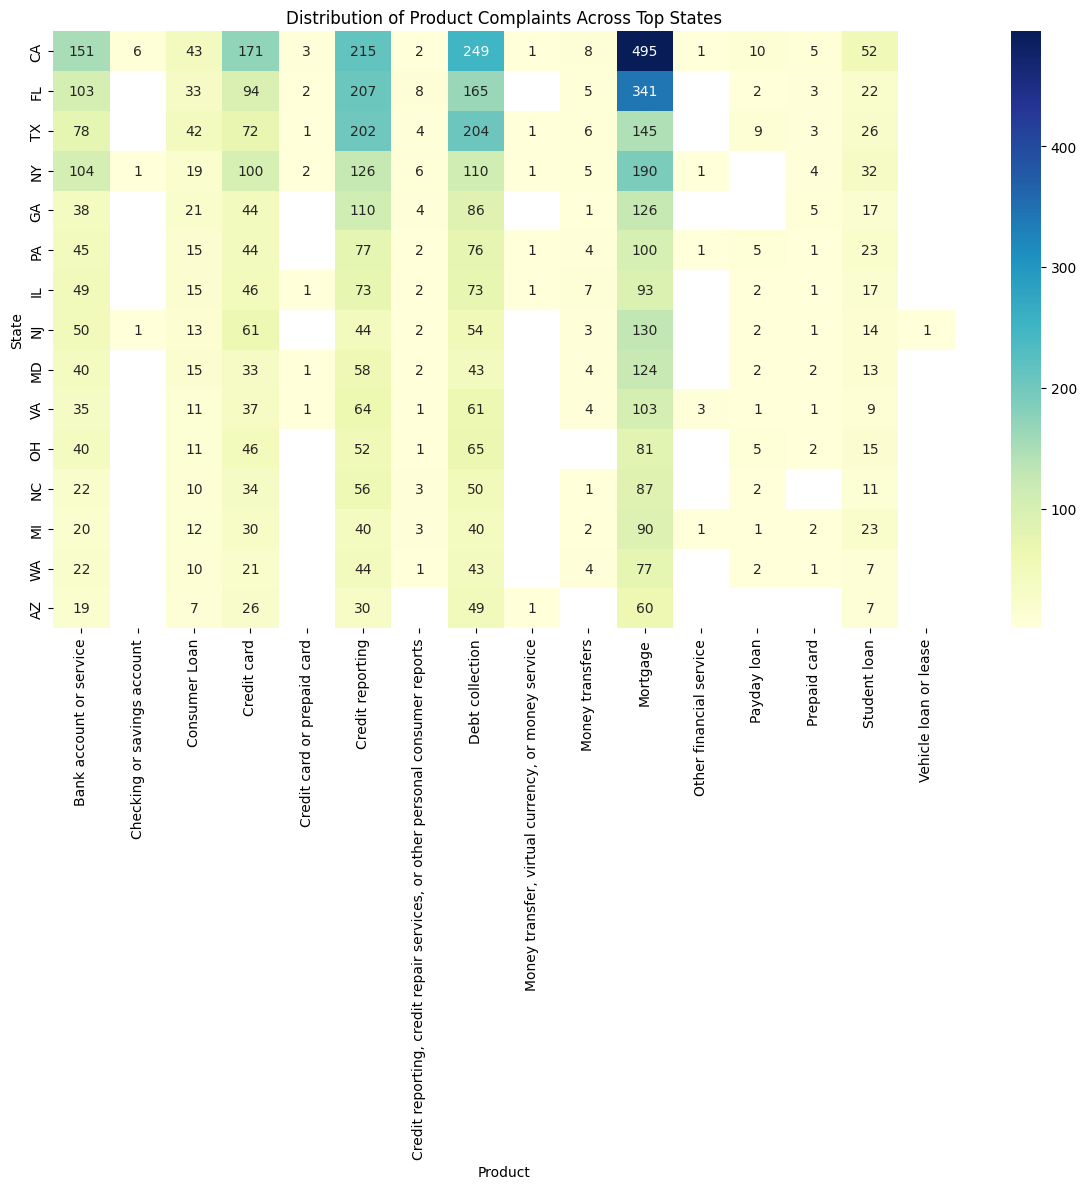

In [14]:
plt.figure(figsize=(12, 12))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Distribution of Product Complaints Across Top States')
plt.xlabel('Product')
plt.ylabel('State')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
target_columns = ['Product', 'Sub-product']
input_columns = ['Consumer Complaint', 'Issue', 'Sub-issue']
all_relevant_columns = target_columns + input_columns

# Create a new DataFrame with only the specified columns from the original 'data'
df_model = data[all_relevant_columns].copy()

# Fill missing values in the input and sub-target columns with an empty string
df_model['Consumer Complaint'] = df_model['Consumer Complaint'].fillna('')
df_model['Sub-issue'] = df_model['Sub-issue'].fillna('')
df_model['Sub-product'] = df_model['Sub-product'].fillna('') # Fill NaN for Sub-product target

# Verify that there are no missing values in the selected columns
print("Missing values in the final DataFrame for modeling:")
display(df_model.isnull().sum())

# Display the head of the new DataFrame
print("\nHead of the DataFrame for modeling:")
display(df_model.head())

# Display the shape to confirm columns were dropped
print(f"\nShape of the modeling DataFrame: {df_model.shape}")

Missing values in the final DataFrame for modeling:


,0
Product,0
Sub-product,0
Consumer Complaint,0
Issue,0
Sub-issue,0



Head of the DataFrame for modeling:


,Product,Sub-product,Consumer Complaint,Issue,Sub-issue
0,Mortgage,Other mortgage,,"Loan modification,collection,foreclosure",
1,Credit reporting,,I have outdated information on my credit repor...,Incorrect information on credit report,Account status
2,Consumer Loan,Vehicle loan,I purchased a new car on XXXX XXXX. The car de...,Managing the loan or lease,
3,Credit card,,,Bankruptcy,
4,Debt collection,Credit card,,Communication tactics,Frequent or repeated calls



Shape of the modeling DataFrame: (9999, 5)


### Step 2: Data Splitting

Now that our data is prepared, the next step is to split it into training and testing sets. This allows us to train our classification model on a portion of the data and then evaluate its performance on unseen data. We'll use an 80/20 split, where 80% of the data is used for training and 20% for testing.

In [16]:
from sklearn.model_selection import train_test_split

# Combine text input columns into a single feature
df_model['combined_text'] = df_model['Consumer Complaint'] + " " + df_model['Issue'] + " " + df_model['Sub-issue']

# Define features (X) and target (y)
X = df_model['combined_text']
y = df_model['Product']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Display the first few entries of the training data
print("\nFirst 5 entries of X_train:")
display(X_train.head())
print("\nFirst 5 entries of y_train:")
display(y_train.head())

Shape of X_train: (7999,)
Shape of X_test: (2000,)
Shape of y_train: (7999,)
Shape of y_test: (2000,)

First 5 entries of X_train:


,combined_text
4008,Incorrect information on credit report Accoun...
403,On XX/XX/2016 I called XXXX UVerse to cancel X...
2872,"Loan servicing, payments, escrow account"
3223,Incorrect information on credit report Accoun...
6509,"Loan modification,collection,foreclosure"



First 5 entries of y_train:


,Product
4008,Credit reporting
403,Debt collection
2872,Mortgage
3223,Credit reporting
6509,Mortgage


### Step 3: Text Vectorization

Before we can train a classification model, we need to convert our text data (`combined_text`) into numerical feature vectors. We will use **TF-IDF (Term Frequency-Inverse Document Frequency)**, a common and effective method for this purpose in text classification tasks. TF-IDF reflects the importance of a word in a document relative to a corpus.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# min_df ignores terms that have a document frequency strictly lower than the given threshold.
# max_df ignores terms that have a document frequency strictly higher than the given threshold.
# ngram_range to include single words and two-word phrases.
# stop_words='english' removes common English stop words.
vectorizer = TfidfVectorizer(min_df=5, max_df=0.8, ngram_range=(1, 2), stop_words='english')

# Fit the vectorizer on the training data and transform both training and test data
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print(f"Shape of X_train_vectorized: {X_train_vectorized.shape}")
print(f"Shape of X_test_vectorized: {X_test_vectorized.shape}")

Shape of X_train_vectorized: (7999, 5262)
Shape of X_test_vectorized: (2000, 5262)


### Step 4: Build and Train a Classification Pipeline

To streamline the process of vectorization and classification, and to ensure consistent preprocessing for future predictions, we'll create a machine learning pipeline. This pipeline will first apply the TF-IDF vectorization and then train a classification model. We'll start with **Logistic Regression**, a robust and widely used algorithm for text classification due to its efficiency and interpretability.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train a Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and L1/L2 regularization
logistic_model.fit(X_train_vectorized, y_train)

# Make predictions on the test set
y_pred_logistic = logistic_model.predict(X_test_vectorized)

# Evaluate the model
print("\n--- Model Evaluation (Logistic Regression) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logistic):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

# You can also test with a custom input
# For custom input, we'd need to vectorize it using the *same* fitted vectorizer
print("\n--- Testing with a custom input ---")
custom_complaint = "My bank charged me an unexpected fee on my checking account."
custom_complaint_vectorized = vectorizer.transform([custom_complaint])
predicted_product = logistic_model.predict(custom_complaint_vectorized)
print(f"Custom complaint: '{custom_complaint}'")
print(f"Predicted Product: {predicted_product[0]}")


--- Model Evaluation (Logistic Regression) ---
Accuracy: 0.9665

Classification Report:
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.98      0.99      0.98       218
                                                 Checking or savings account       0.00      0.00      0.00         2
                                                               Consumer Loan       0.94      0.91      0.92        79
                                                                 Credit card       0.88      1.00      0.94       233
                                                 Credit card or prepaid card       0.00      0.00      0.00         2
                                                            Credit reporting       0.98      1.00      0.99       364
Credit reporting, credit repair services, or other personal consumer reports       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Step 5: Train and Evaluate a Multinomial Naive Bayes Model

Following the strategy of training and comparing multiple models, we'll now apply a **Multinomial Naive Bayes** classifier. This model is particularly well-suited for text classification tasks where features represent counts or frequencies (like TF-IDF values), and it often serves as a strong baseline due to its simplicity and efficiency.

In [19]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train a Multinomial Naive Bayes model
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train_vectorized, y_train)

# Make predictions on the test set
y_pred_nb = naive_bayes_model.predict(X_test_vectorized)

# Evaluate the model
print("\n--- Model Evaluation (Multinomial Naive Bayes) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


--- Model Evaluation (Multinomial Naive Bayes) ---
Accuracy: 0.9455

Classification Report:
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.97      0.98      0.97       218
                                                 Checking or savings account       0.00      0.00      0.00         2
                                                               Consumer Loan       0.92      0.87      0.90        79
                                                                 Credit card       0.83      0.87      0.85       233
                                                 Credit card or prepaid card       0.00      0.00      0.00         2
                                                            Credit reporting       0.94      1.00      0.97       364
Credit reporting, credit repair services, or other personal consumer reports    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Step 6: Train and Evaluate a Support Vector Machine (SVM) Model

To continue our model comparison, we'll now train a **Support Vector Machine (SVM)** classifier. SVMs are well-suited for high-dimensional data like vectorized text and often provide strong performance by finding the optimal hyperplane to separate classes. We'll use a linear kernel for efficiency and interpretability.

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train a Support Vector Machine (SVM) model
# Using a linear kernel is often effective for text classification with TF-IDF
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_vectorized, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_vectorized)

# Evaluate the model
print("\n--- Model Evaluation (Support Vector Machine) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


--- Model Evaluation (Support Vector Machine) ---
Accuracy: 0.9690

Classification Report:
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.96      0.98      0.97       218
                                                 Checking or savings account       0.00      0.00      0.00         2
                                                               Consumer Loan       0.93      0.96      0.94        79
                                                                 Credit card       0.88      0.98      0.93       233
                                                 Credit card or prepaid card       0.00      0.00      0.00         2
                                                            Credit reporting       0.99      1.00      0.99       364
Credit reporting, credit repair services, or other personal consumer reports     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Step 7: Build the Final Prediction Pipeline

Now that we've identified the Support Vector Machine (SVM) model as the best performer, we'll build a complete machine learning pipeline. This pipeline will encapsulate both the TF-IDF vectorization step and the SVM classifier, ensuring that any new input data is preprocessed and classified consistently. This is crucial for deployment and making predictions on unseen data.


In [21]:
from sklearn.pipeline import Pipeline

# Create the pipeline with the TF-IDF vectorizer and the SVM model
final_pipeline = Pipeline(
    [('tfidf', vectorizer), # The TF-IDF vectorizer fitted earlier
    ('svm', svm_model)]     # The trained SVM model
)

# Test the pipeline with a custom input
print("\n--- Testing the final pipeline with a custom input ---")
custom_complaint_pipeline = "My bank charged me an unexpected fee on my checking account."
predicted_product_pipeline = final_pipeline.predict([custom_complaint_pipeline])
print(f"Custom complaint: '{custom_complaint_pipeline}'")
print(f"Predicted Product (from pipeline): {predicted_product_pipeline[0]}")


--- Testing the final pipeline with a custom input ---
Custom complaint: 'My bank charged me an unexpected fee on my checking account.'
Predicted Product (from pipeline): Bank account or service


In [22]:
import joblib

# Define the filename for your model pipeline
pipeline_filename = 'complaint_classifier_pipeline.joblib'

# Save the trained pipeline to a file
joblib.dump(final_pipeline, pipeline_filename)

print(f"Model pipeline successfully saved as '{pipeline_filename}'")
print("You can now download this file and use it in your Streamlit/Gradio application for deployment on Hugging Face Spaces.")

Model pipeline successfully saved as 'complaint_classifier_pipeline.joblib'
You can now download this file and use it in your Streamlit/Gradio application for deployment on Hugging Face Spaces.


In [23]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 92.6 MB/s eta 0:00:00


In [24]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
⠸⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) ^C
